In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('language.csv').drop_duplicates()
df.head()

,Text,language
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian
1,sebes joseph pereira thomas på eng the jesuit...,Swedish
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil
4,de spons behoort tot het geslacht haliclona en...,Dutch


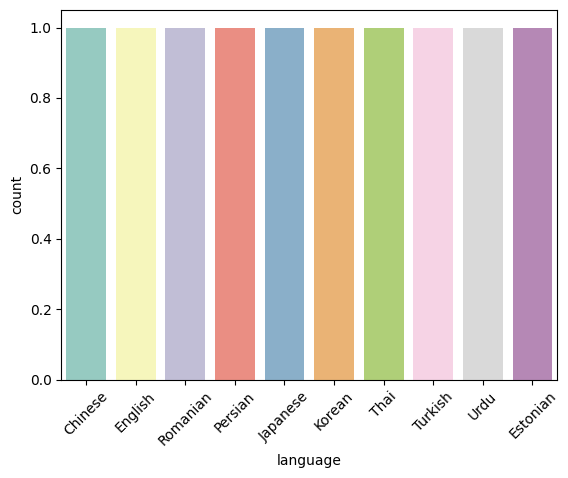

In [3]:
top10 = df.groupby('language').size().sort_values(ascending=False).head(10)
sns.countplot(data=top10,palette='Set3')

plt.xticks(rotation=45)
plt.show()

In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # remove links
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Text'].apply(clean_text)
df.head()

,Text,language,clean_text
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian,klement gottwaldi surnukeha palsameeriti ning ...
1,sebes joseph pereira thomas på eng the jesuit...,Swedish,sebes joseph pereira thomas på eng the jesuits...
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...
4,de spons behoort tot het geslacht haliclona en...,Dutch,de spons behoort tot het geslacht haliclona en...


In [ ]:
# pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

df['tokenization'] = df['clean_text'].apply(word_tokenize)

# df['tokenization'] = df['clean_text'].apply(lambda x: x.split())

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gamin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [7]:
df.head()

,Text,language,clean_text,tokenization
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian,klement gottwaldi surnukeha palsameeriti ning ...,"[klement, gottwaldi, surnukeha, palsameeriti, ..."
1,sebes joseph pereira thomas på eng the jesuit...,Swedish,sebes joseph pereira thomas på eng the jesuits...,"[sebes, joseph, pereira, thomas, på, eng, the,..."
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,"[ถนนเจริญกรุง, อักษรโรมัน, thanon, charoen, kr..."
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,"[விசாகப்பட்டினம், தமிழ்ச்சங்கத்தை, இந்துப், பத..."
4,de spons behoort tot het geslacht haliclona en...,Dutch,de spons behoort tot het geslacht haliclona en...,"[de, spons, behoort, tot, het, geslacht, halic..."


In [8]:
from nltk.corpus import stopwords

stop = set(stopwords.words('english'))

df['tokenization'] = df['tokenization'].apply(
    lambda words :[ word for word in words if word not in stop]
)

In [9]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

df['tokenization'] = df['tokenization'].apply(
    lambda words :[stemmer.stem(word) for word in words]
)

In [11]:
# vectorization :

df['processed_text'] = df['tokenization'].apply(lambda x : " ".join(x))

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['processed_text'])
y = df['language']

In [12]:
from sklearn.naive_bayes import MultinomialNB

model1 = MultinomialNB()

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

model1.fit(X_train,y_train)

y_pred = model1.predict(X_test)

print(model1.score(X_train,y_train))
print(model1.score(X_test,y_test))

0.9897066392177046
0.9565416285452882


In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       193
     Chinese       0.93      0.55      0.69       192
       Dutch       0.99      0.98      0.99       191
     English       0.71      0.99      0.83       202
    Estonian       0.99      0.97      0.98       194
      French       0.93      1.00      0.96       178
       Hindi       0.99      0.98      0.98       164
  Indonesian       1.00      0.97      0.98       220
    Japanese       0.69      0.82      0.75       176
      Korean       1.00      0.98      0.99       215
       Latin       0.99      0.95      0.97       217
     Persian       1.00      0.99      1.00       193
   Portugese       0.99      0.99      0.99       190
      Pushto       1.00      0.96      0.98       186
    Romanian       0.99      0.99      0.99       222
     Russian       0.99      0.99      0.99       192
     Spanish       0.99      0.96      0.97       211
     Swedish       0.99    

In [14]:
# prediction :
def prediction_text(text):
    text = clean_text(text)
    vec = tfidf.transform([text])
    pred = model1.predict(vec)
    return pred[0]

In [15]:
print(prediction_text('हिमांशु नाम के लड़के आमतौर पर शांत,'))
print(prediction_text("radhey radhey my name is apple"))

Hindi
English


### USING Fast Api

In [ ]:
# pip install fastapi uvicorn

In [17]:
import sys
print(sys.executable)

c:\Users\gamin\OneDrive\Desktop\NLP Dataset\myclass\Scripts\python.exe


In [21]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('vectorizer',tfidf),
    ('model',model1)
])

import pickle

try:
    with open("pipeline.pkl","wb") as f:
        pickle.dump(pipeline,f)
    print("succefully saved the pipline i mean model")
except:
    print("error")

succefully saved the pipline i mean model
